In [1]:
import time

import astropy.units as u
import batoid
import numpy as np
from astropy.coordinates import Angle
from StarSharp.datatypes.state import StateFactory
from batoid_rubin import LSSTBuilder
from lsst.obs.lsst import LsstCam

from StarSharp.models.raytraced import RaytracedOpticalModel
from StarSharp.models.linear import LinearSpotModel
from StarSharp import State

import matplotlib.pyplot as plt

In [2]:
# Build a raytraced model
telescope = batoid.Optic.fromYaml("LSST_r.yaml")
builder = LSSTBuilder(
    telescope,
    # Set coords/units to match MTAOS
    dof_coord_system="OCS",
    flip_m2_bending_modes=False,
    dof_angle_units="degree"
)
camera = LsstCam().getCamera()
model = RaytracedOpticalModel(
    builder,
    rtp = Angle("20 deg"),
    wavelength=620 * u.nm,
    camera=camera
)
fc = model.make_ccd_field(detnums=list(range(4, 189, 9))) # Raft centers

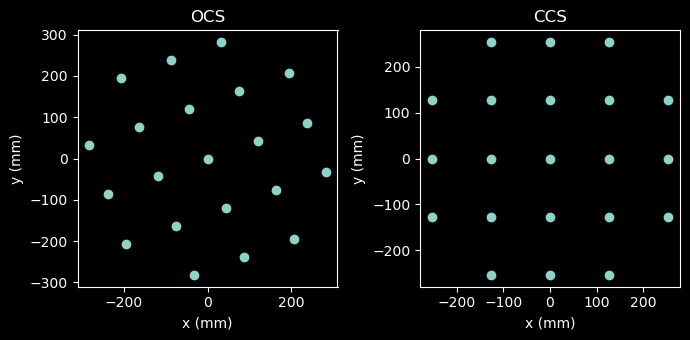

In [3]:
# Got field coordinates in both OCS and CCS:
fig, axs = plt.subplots(ncols=2, figsize=(7, 3.5))
axs[0].set_title("OCS")
axs[0].set_xlabel("x (mm)")
axs[0].set_ylabel("y (mm)")
axs[1].set_title("CCS")
axs[1].set_xlabel("x (mm)")
axs[1].set_ylabel("y (mm)")
axs[0].scatter(fc.ocs.x, fc.ocs.y)
axs[1].scatter(fc.ccs.x, fc.ccs.y)
plt.tight_layout()
plt.show()

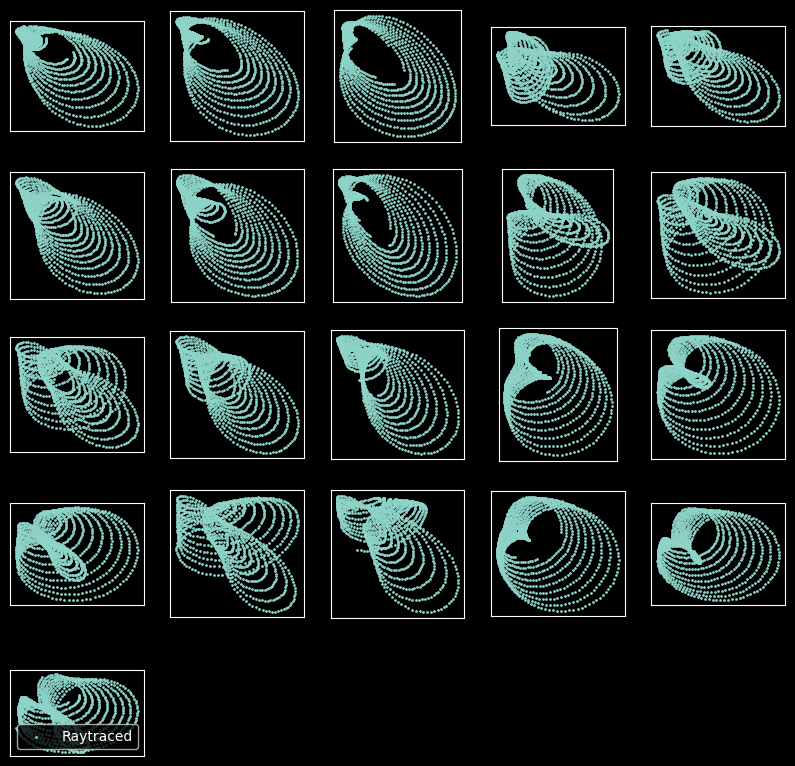

In [10]:
use_dof = list(range(17))+list(range(30,37))

# Get spots
steps = model.steps[use_dof] # Default differential step sizes for each DOF
rng = np.random.default_rng(12345)
state = State(
    value=rng.normal(0.0, size=24) * steps,
    basis="x",
    use_dof=use_dof,
    n_dof=50
)
mspots = model.spots(fc, state)

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for ax, mspot in zip(axs.flat, mspots):
    ax.scatter(
        mspot.dx[~mspot.vignetted], mspot.dy[~mspot.vignetted],
        color="C0", label="Raytraced", s=1
    )
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axs[4,1:]:
    fig.delaxes(ax)
plt.legend()
plt.show()

In [5]:
t0 = time.time()
rng = np.random.default_rng(123)
for _ in range(50):
    state = State(
        value=rng.normal(0.0, size=24) * steps,
        basis="x",
        use_dof=use_dof,
        n_dof=50
    )
    _ = model.spots(fc, state)
t1 = time.time()
print(f"Time for 50 iterations: {t1 - t0} seconds")

Time for 50 iterations: 6.329415798187256 seconds


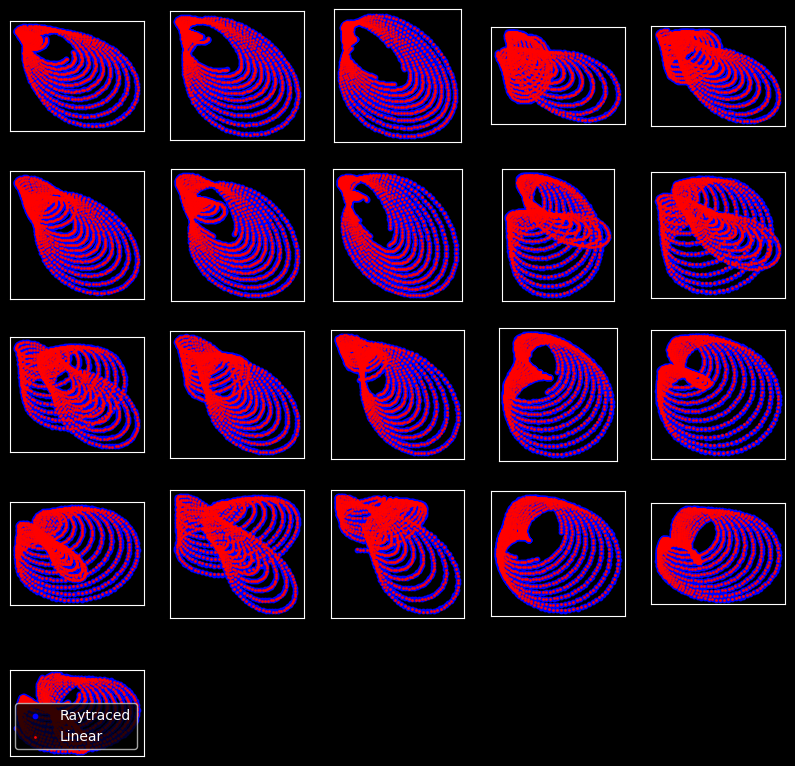

In [11]:
# Linearized model
spot_model = LinearSpotModel(
    raytraced=model,
    # Have to declare the field and use_dof up front
    field=fc,
    use_dof=use_dof,
)

# First execution builds the sensitivity matrix internally,
# should be fast after that.
rng = np.random.default_rng(12345)
state = State(
    value=rng.normal(0.0, size=24) * steps,
    basis="x",
    use_dof=use_dof,
    n_dof=50
)
lspots = spot_model.spots(state)

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for ax, mspot, lspot in zip(axs.flat, mspots, lspots):
    ax.scatter(
        mspot.dx[~mspot.vignetted], mspot.dy[~mspot.vignetted],
        color="b", label="Raytraced", s=10
    )
    ax.scatter(
        lspot.dx[~lspot.vignetted], lspot.dy[~lspot.vignetted],
        color="r", label="Linear", s=1
    )
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axs[4,1:]:
    fig.delaxes(ax)
plt.legend()
plt.show()

In [7]:
t0 = time.time()
rng = np.random.default_rng(123)
for _ in range(50):
    state = State(
        value=rng.normal(0.0, size=24) * steps,
        basis="x",
        use_dof=use_dof,
        n_dof=50
    )
    _ = spot_model.spots(state)
t1 = time.time()
print(f"Time for 50 iterations: {t1 - t0} seconds")


Time for 50 iterations: 0.01886892318725586 seconds


In [8]:
# Compare moments
m2 = mspots.moments()
l2 = lspots.moments()
for i in range(len(m2.xx)):
    print()
    print(f"{m2.xx[i]:.3f} vs {l2.xx[i]:.3f}")
    print(f"{m2.yy[i]:.3f} vs {l2.yy[i]:.3f}")
    print(f"{m2.T[i]:.3f} vs {l2.T[i]:.3f}")
    print(f"{m2.e1[i]:.3f} vs {l2.e1[i]:.3f}")
    print(f"{m2.e2[i]:.3f} vs {l2.e2[i]:.3f}")



692.843 micron2 vs 698.062 micron2
405.835 micron2 vs 409.072 micron2
1098.677 micron2 vs 1107.134 micron2
0.261 vs 0.261
-0.662 vs -0.661

747.527 micron2 vs 751.301 micron2
507.071 micron2 vs 509.670 micron2
1254.598 micron2 vs 1260.971 micron2
0.192 vs 0.192
-0.613 vs -0.612

1024.382 micron2 vs 1028.710 micron2
756.446 micron2 vs 759.252 micron2
1780.828 micron2 vs 1787.962 micron2
0.150 vs 0.151
-0.535 vs -0.535

491.969 micron2 vs 494.049 micron2
312.475 micron2 vs 312.860 micron2
804.444 micron2 vs 806.908 micron2
0.223 vs 0.225
-0.786 vs -0.786

491.268 micron2 vs 493.616 micron2
264.227 micron2 vs 265.363 micron2
755.495 micron2 vs 758.978 micron2
0.301 vs 0.301
-0.769 vs -0.769

531.362 micron2 vs 534.343 micron2
283.577 micron2 vs 285.817 micron2
814.939 micron2 vs 820.159 micron2
0.304 vs 0.303
-0.675 vs -0.675

619.263 micron2 vs 622.649 micron2
352.838 micron2 vs 355.421 micron2
972.100 micron2 vs 978.071 micron2
0.274 vs 0.273
-0.542 vs -0.541

840.117 micron2 vs 844.94